In [1]:
# ============================================================
# Cell 1: Imports, mesh, CG solve
# ============================================================
from mpi4py import MPI
import numpy as np
import torch
import torch.nn as nn
import math
import basix
import matplotlib.pyplot as plt
from tqdm import tqdm

from dolfinx import mesh, fem, default_scalar_type
from dolfinx.io import gmsh as gmshio
from dolfinx.fem import petsc
import ufl

# ---- Mesh ----
ref = 4  # mesh refinement level (increase for finer mesh)
filename = f"regular_mesh_{ref}.msh"
omega, cell_markers, facet_markers = gmshio.read_from_msh(
    filename, MPI.COMM_WORLD, 0, gdim=2
)[0:3]

tdim = omega.topology.dim   # 2
fdim = tdim - 1              # 1
gdim = 2

lc = 1.0 / (2**ref)
h  = lc

# ---- Function space (CG1) ----
order = 1
V = fem.functionspace(omega, ("Lagrange", order))

phi = ufl.TestFunction(V)
p   = fem.Function(V, name="p")
dp  = ufl.TrialFunction(V)

# ---- Data: k, f ----
x = ufl.SpatialCoordinate(omega)

f_m = -x[1]**2 - 2*x[0]**2

def f_callable(x):
    return -x[1]**2 - 2*x[0]**2

def k_callable(x):
    return (2 * x[0])[np.newaxis, :]

k_m = fem.Function(V, name="kappa")
k_m.interpolate(k_callable)

f_func = fem.Function(V)
f_func.interpolate(f_callable)

# ---- Geometry for BCs ----
coords = omega.geometry.x
xmin, xmax = coords[:, 0].min(), coords[:, 0].max()
ymin, ymax = coords[:, 1].min(), coords[:, 1].max()
tol = 1e-10 * max(xmax - xmin, ymax - ymin)

# ---- Neumann tags (top/bottom) ----
bottom_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[1], ymin, atol=tol))
top_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[1], ymax, atol=tol))

indices = np.concatenate([bottom_facets, top_facets]).astype(np.int32)
values  = np.concatenate([
    np.full(bottom_facets.shape, 10, dtype=np.int32),
    np.full(top_facets.shape,    20, dtype=np.int32),
])
neumann_tags = mesh.meshtags(omega, fdim, indices, values)
dsN = ufl.Measure("ds", domain=omega, subdomain_data=neumann_tags)

g_top    = 2 * x[0]**2
g_bottom = 0.0

# ---- Weak form ----
a = ufl.inner(k_m * ufl.grad(dp), ufl.grad(phi)) * ufl.dx
L = (f_m * phi * ufl.dx
     + g_bottom * phi * dsN(10)
     + g_top    * phi * dsN(20))

# ---- Dirichlet BCs (left x=0, right x=1) ----
left_dofs  = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], xmin, atol=tol))
right_dofs = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], xmax, atol=tol))
all_dofs   = np.unique(np.concatenate([left_dofs, right_dofs]))

dof_coords = V.tabulate_dof_coordinates()
p_bc = fem.Function(V)
p_bc.x.array[left_dofs]  = 0.0
p_bc.x.array[right_dofs] = dof_coords[right_dofs, 1]**2 / 2.0
bc = fem.dirichletbc(p_bc, all_dofs)

# ---- Solve (dolfinx 0.10+: petsc_options_prefix is required) ----
problem = petsc.LinearProblem(
    a=a, L=L, bcs=[bc],
    petsc_options_prefix="lcg_cg_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    }
)
p_sol = problem.solve()
p_sol.name = "pressure"
print(f"DOFs: {V.dofmap.index_map.size_global}")


Info    : Reading 'regular_mesh_4.msh'...
Info    : 2337 entities
Info    : 289 nodes
Info    : 2337 elements
Info    : Done reading 'regular_mesh_4.msh'
DOFs: 289


In [2]:
# ============================================================
# Cell 2: Mesh connectivity + build DG1 q_CG function
# ============================================================

# Cell-vertex connectivity
omega.topology.create_connectivity(tdim, 0)
ctv = omega.topology.connectivity(tdim, 0)
num_cells = omega.topology.index_map(tdim).size_local
local_cell_vertices = np.array([ctv.links(c) for c in range(num_cells)])
omega_geometry = omega.geometry.x[:, :2]  # (num_vertices, 2)

# Build DG1 vector function for q_CG = -k * grad(p)
# (DG1 captures the piecewise-linear nature of k * grad(p))
Vq = fem.functionspace(omega, ("DG", 1, (gdim,)))
q_cg_fun = fem.Function(Vq, name="q_CG")

q_expr = fem.Expression(
    -k_m * ufl.grad(p_sol),
    Vq.element.interpolation_points
)
q_cg_fun.interpolate(q_expr)

print(f"Cells: {num_cells}, Vertices: {omega_geometry.shape[0]}")
print(f"DG1 DOFs: {Vq.dofmap.index_map.size_global * Vq.dofmap.bs}")


Cells: 512, Vertices: 289
DG1 DOFs: 3072


In [3]:
# ============================================================
# Cell 3: Extract training data
#   For each element: 1 centroid + n_boundary_pts per edge
#   Generalized: change n_boundary_pts to scale up
# ============================================================

def extract_training_data(q_cg_fun, local_cell_vertices, omega_geometry,
                           n_boundary_pts=3, device="cpu"):
    """
    Parameters
    ----------
    n_boundary_pts : int
        Number of uniformly spaced sample points per edge.
        Positions are placed at the midpoints of equal sub-intervals
        (avoids endpoints which are shared with other edges).

    Returns
    -------
    X_all    : (N, 2) all sample coordinates (centroid first per cell)
    Q_all    : (N, 2) q_CG values at those coordinates
    F_all    : (N,)   analytical f = -y^2 - 2x^2 at those coordinates
    X_cent   : (num_cells, 2) centroid coordinates
    cell_ids : (N,) cell index for each sample point
    is_centroid : (N,) bool — True for centroid points
    """
    edges_loc = [(0, 1), (1, 2), (2, 0)]
    points_list   = []
    cell_ids_list = []
    is_cent_list  = []

    for cell_idx, cell_verts in enumerate(local_cell_vertices):
        coords = omega_geometry[cell_verts]  # (3, 2)

        # --- centroid ---
        centroid = coords.mean(axis=0)
        points_list.append(centroid)
        cell_ids_list.append(cell_idx)
        is_cent_list.append(True)

        # --- boundary points ---
        for (v0, v1) in edges_loc:
            x0, x1 = coords[v0], coords[v1]
            for k in range(n_boundary_pts):
                # midpoints of equal sub-intervals → avoids shared vertices
                t = (2*k + 1) / (2 * n_boundary_pts)
                pt = x0 + t * (x1 - x0)
                points_list.append(pt)
                cell_ids_list.append(cell_idx)
                is_cent_list.append(False)

    X_np        = np.array(points_list,   dtype=np.float64)   # (N, 2)
    cell_ids_np = np.array(cell_ids_list, dtype=np.int32)     # (N,)
    is_cent_np  = np.array(is_cent_list,  dtype=bool)         # (N,)

    # Batch-evaluate q_CG
    pts_3d = np.column_stack([X_np, np.zeros(len(X_np))])
    Q_np   = q_cg_fun.eval(pts_3d, cell_ids_np)               # (N, 2)

    # Analytical f at every point
    F_np = -X_np[:, 1]**2 - 2*X_np[:, 0]**2                  # (N,)

    X_cent_np = X_np[is_cent_np]

    return (
        torch.tensor(X_np,       dtype=torch.float32, device=device),
        torch.tensor(Q_np,       dtype=torch.float32, device=device),
        torch.tensor(F_np,       dtype=torch.float32, device=device),
        torch.tensor(X_cent_np,  dtype=torch.float32, device=device),
        cell_ids_np,
        is_cent_np,
    )


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_boundary_pts = 3   # ← change here to use more boundary sample points

X_all, Q_all, F_all, X_cent, cell_ids, is_centroid = extract_training_data(
    q_cg_fun, local_cell_vertices, omega_geometry,
    n_boundary_pts=n_boundary_pts, device=device
)

print(f"Total training points : {X_all.shape[0]}")
print(f"  Centroids            : {X_cent.shape[0]}")
print(f"  Boundary pts/cell    : {3 * n_boundary_pts}")
print(f"  Points per cell      : {1 + 3 * n_boundary_pts}")


Total training points : 5120
  Centroids            : 512
  Boundary pts/cell    : 9
  Points per cell      : 10


In [4]:
# ============================================================
# Cell 4: Neural network definition
#   q_rec : R^2 → R^2  (continuous, smooth approximation to CG flux)
# ============================================================

class FluxNet(nn.Module):
    """Continuous vector flux network q_rec: R² → R²"""

    def __init__(self, hidden_dim=64, n_layers=4, activation=nn.Tanh):
        super().__init__()
        layers  = [nn.Linear(2, hidden_dim), activation()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), activation()]
        layers += [nn.Linear(hidden_dim, 2)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


net = FluxNet(hidden_dim=64, n_layers=4).to(device)
print(f"Parameters: {sum(p.numel() for p in net.parameters())}")


Parameters: 12802


In [5]:
# ============================================================
# Cell 5: Loss functions
# ============================================================

def compute_divergence(net, x):
    """div(q_rec) at points x using autograd. x must require grad."""
    q    = net(x)           # (N, 2)
    div_q = torch.zeros(x.shape[0], device=x.device)
    for j in range(2):
        g = torch.autograd.grad(
            q[:, j].sum(), x,
            create_graph=True, retain_graph=True
        )[0]                # (N, 2)
        div_q = div_q + g[:, j]
    return div_q


def compute_loss(net, X_all, Q_all, F_all, is_centroid_mask, W_data=1.0, W_pde=1.0):
    """
    Two-term loss:
      L = W_data * MSE(q_rec(x_i), q_CG(x_i))   [all sample points]
        + W_pde  * MSE(div q_rec(x_j), f(x_j))   [all sample points]

    Returns total, data_loss, pde_loss.
    """
    # ---- Data fitting (all points, no grad needed for x) ----
    q_pred    = net(X_all)
    loss_data = torch.mean((q_pred - Q_all) ** 2)

    # ---- PDE residual (need grad w.r.t. x) ----
    X_pde  = X_all.clone().detach().requires_grad_(True)
    div_q  = compute_divergence(net, X_pde)
    loss_pde = torch.mean((div_q - F_all) ** 2)

    total = W_data * loss_data + W_pde * loss_pde
    return total, loss_data, loss_pde


In [6]:
# ============================================================
# Cell 6: Training
# ============================================================

optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)

max_epochs = 3000
W_data = 1.0
W_pde  = 1.0

history = {"total": [], "data": [], "pde": []}

is_centroid_mask = torch.tensor(is_centroid, device=device)

best_loss  = float("inf")
best_state = None

for epoch in tqdm(range(max_epochs)):
    optimizer.zero_grad()

    loss, l_data, l_pde = compute_loss(
        net, X_all, Q_all, F_all, is_centroid_mask, W_data, W_pde
    )
    loss.backward()
    optimizer.step()
    scheduler.step()

    history["total"].append(loss.item())
    history["data"].append(l_data.item())
    history["pde"].append(l_pde.item())

    if loss.item() < best_loss:
        best_loss  = loss.item()
        best_state = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}

net.load_state_dict(best_state)
print(f"Best total loss : {best_loss:.4e}")
print(f"  Data loss     : {history['data'][np.argmin(history['total'])]:.4e}")
print(f"  PDE loss      : {history['pde'][np.argmin(history['total'])]:.4e}")


100%|██████████| 3000/3000 [01:51<00:00, 26.79it/s]

Best total loss : 9.7111e-04
  Data loss     : 9.0699e-04
  PDE loss      : 6.4127e-05


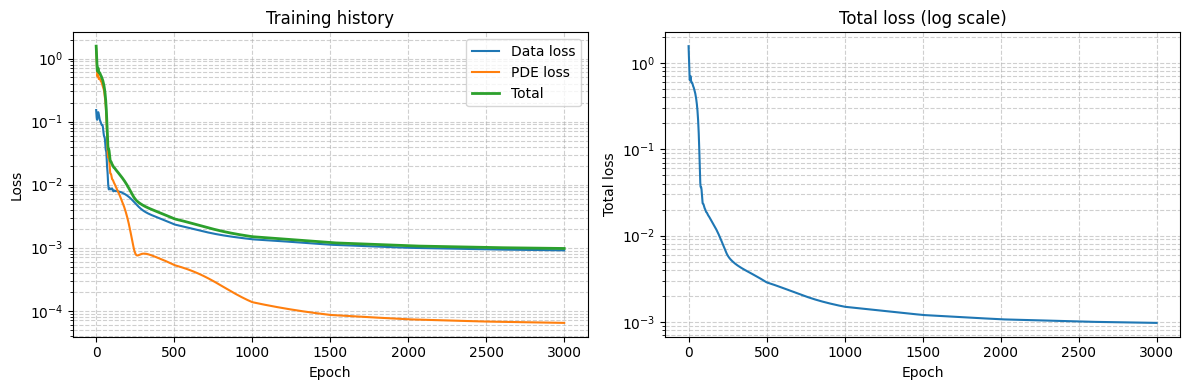

In [7]:
# ============================================================
# Cell 7: Training loss history plot
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(history["data"],  label="Data loss")
axes[0].semilogy(history["pde"],   label="PDE loss")
axes[0].semilogy(history["total"], label="Total", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training history")
axes[0].legend()
axes[0].grid(True, which="both", linestyle="--", alpha=0.6)

axes[1].semilogy(history["total"])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Total loss")
axes[1].set_title("Total loss (log scale)")
axes[1].grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [8]:
# ============================================================
# Cell 8: Local Conservation Error (LCE) per element
#
#   LCE_K = ∫_{∂K} q·n ds  -  ∫_K f dx
#
# Computed for both q_CG (before) and q_rec (after).
# ============================================================

def build_edge_quadrature(local_cell_vertices, omega_geometry, n_gl=2):
    """
    Precompute all edge Gauss-Legendre points and outward normals for
    the batch evaluation of ∫_{∂K} q·n ds over every cell.

    Uses n_gl-point GL rule on each edge (exact for polynomials of
    degree ≤ 2*n_gl - 1, so n_gl=2 is exact for DG1 fluxes).

    Returns
    -------
    pts_np       : (N_pts, 2)  physical coords of all quadrature points
    cell_ids_np  : (N_pts,)    cell index for each point
    normals_np   : (N_pts, 2)  outward unit normal for each point
    lengths_np   : (N_pts,)    edge length for each point
    weights_np   : (N_pts,)    quadrature weight for each point
    """
    # GL rule on [0, 1]
    if n_gl == 1:
        xi_np = np.array([0.5])
        wi_np = np.array([1.0])
    elif n_gl == 2:
        xi_np = np.array([0.5*(1 - 1/math.sqrt(3)), 0.5*(1 + 1/math.sqrt(3))])
        wi_np = np.array([0.5, 0.5])
    elif n_gl == 3:
        xi_np = np.array([0.5*(1 - math.sqrt(3/5)), 0.5, 0.5*(1 + math.sqrt(3/5))])
        wi_np = np.array([5/18, 8/18, 5/18])
    else:
        raise ValueError("n_gl must be 1, 2, or 3")

    edges_loc = [(0, 1), (1, 2), (2, 0)]
    pts_list     = []
    cell_list    = []
    normal_list  = []
    length_list  = []
    weight_list  = []

    for cell_idx, cell_verts in enumerate(local_cell_vertices):
        coords   = omega_geometry[cell_verts]   # (3, 2)
        centroid = coords.mean(axis=0)

        for (v0, v1) in edges_loc:
            x0 = coords[v0]
            x1 = coords[v1]
            t  = x1 - x0
            L  = np.linalg.norm(t)
            if L <= 1e-15:
                continue

            # Outward normal (oriented away from centroid)
            n = np.array([t[1], -t[0]]) / L
            midpoint = 0.5 * (x0 + x1)
            if np.dot(n, centroid - midpoint) > 0:
                n = -n

            for k in range(n_gl):
                pt = x0 + xi_np[k] * t
                pts_list.append(pt)
                cell_list.append(cell_idx)
                normal_list.append(n)
                length_list.append(L)
                weight_list.append(wi_np[k])

    return (
        np.array(pts_list,    dtype=np.float64),
        np.array(cell_list,   dtype=np.int32),
        np.array(normal_list, dtype=np.float64),
        np.array(length_list, dtype=np.float64),
        np.array(weight_list, dtype=np.float64),
    )


def compute_int_f_per_cell(local_cell_vertices, omega_geometry, degree=4):
    """
    Exact per-cell integral of f = -y^2 - 2x^2 using triangle Gauss quadrature.
    """
    xi_tri, wi_tri = basix.make_quadrature(basix.CellType.triangle, degree)

    int_f = np.zeros(len(local_cell_vertices))
    for cell_idx, cell_verts in enumerate(local_cell_vertices):
        coords = omega_geometry[cell_verts]     # (3, 2)
        B      = np.column_stack([coords[1] - coords[0],
                                  coords[2] - coords[0]])  # Jacobian (2,2)
        det_B  = abs(np.linalg.det(B))

        val = 0.0
        for xi_k, wi_k in zip(xi_tri, wi_tri):
            x_phys = coords[0] + B @ xi_k
            f_val  = -x_phys[1]**2 - 2*x_phys[0]**2
            val   += wi_k * f_val * det_B
        int_f[cell_idx] = val

    return int_f


# ---- Build edge quadrature data (done once) ----
n_gl = 2  # 2-point GL is exact for DG1 fluxes
pts_eq, cell_ids_eq, normals_eq, lengths_eq, weights_eq = build_edge_quadrature(
    local_cell_vertices, omega_geometry, n_gl=n_gl
)

# ---- ∫_K f dx per cell ----
int_f_cells = compute_int_f_per_cell(local_cell_vertices, omega_geometry)

# ---- ∫_{∂K} q_CG·n ds per cell (batch eval) ----
pts_3d_eq = np.column_stack([pts_eq, np.zeros(len(pts_eq))])
q_cg_at_eq = q_cg_fun.eval(pts_3d_eq, cell_ids_eq)        # (N_pts, 2)
qn_cg     = np.sum(q_cg_at_eq * normals_eq, axis=1) * lengths_eq * weights_eq

int_qcg = np.zeros(num_cells)
np.add.at(int_qcg, cell_ids_eq, qn_cg)

lce_cg = int_qcg - int_f_cells

# ---- ∫_{∂K} q_rec·n ds per cell (NN eval) ----
pts_eq_t = torch.tensor(pts_eq, dtype=torch.float32, device=device)

with torch.no_grad():
    q_rec_at_eq = net(pts_eq_t).cpu().numpy()              # (N_pts, 2)

qn_rec   = np.sum(q_rec_at_eq * normals_eq, axis=1) * lengths_eq * weights_eq

int_qrec = np.zeros(num_cells)
np.add.at(int_qrec, cell_ids_eq, qn_rec)

lce_rec = int_qrec - int_f_cells

print("LCE before (q_CG):")
print(f"  L∞  : {np.max(np.abs(lce_cg)):.4e}")
print(f"  RMS : {np.sqrt(np.mean(lce_cg**2)):.4e}")
print(f"  mean|·| : {np.mean(np.abs(lce_cg)):.4e}")
print()
print("LCE after (q_rec):")
print(f"  L∞  : {np.max(np.abs(lce_rec)):.4e}")
print(f"  RMS : {np.sqrt(np.mean(lce_rec**2)):.4e}")
print(f"  mean|·| : {np.mean(np.abs(lce_rec)):.4e}")


LCE before (q_CG):
  L∞  : 3.8335e-03
  RMS : 1.7470e-03
  mean|·| : 1.3056e-03

LCE after (q_rec):
  L∞  : 8.7472e-05
  RMS : 1.4630e-05
  mean|·| : 1.0974e-05


In [9]:
# ============================================================
# Cell 9: L2 error comparison with exact solution
#   q_exact = (-x*y^2,  -2*x^2*y)
# ============================================================

def q_exact_np(x):
    """x: (N, 2) → (N, 2)"""
    return np.column_stack([
        -x[:, 0] * x[:, 1]**2,
        -2 * x[:, 0]**2 * x[:, 1]
    ])


# ---- Interpolate q_rec into DG1 function for FEniCSx L2 assembly ----
def interpolate_nn_to_dg(net, Vq, device):
    """Interpolate a PyTorch vector network into a dolfinx DG function."""
    q_fun_nn = fem.Function(Vq)

    def nn_eval(x):
        # x: (3, N_dofs) — dolfinx convention (gdim rows, N_dofs cols)
        pts = np.column_stack([x[0], x[1]]).astype(np.float32)
        with torch.no_grad():
            vals = net(torch.tensor(pts, device=device)).cpu().numpy()  # (N, 2)
        return vals.T   # (2, N)

    q_fun_nn.interpolate(nn_eval)
    return q_fun_nn


q_rec_fun = interpolate_nn_to_dg(net, Vq, device)
q_rec_fun.name = "q_rec"

# ---- Exact flux as DG function ----
q_ex_fun = fem.Function(Vq, name="q_exact")
q_ex_fun.interpolate(lambda x: np.vstack([
    -x[0] * x[1]**2,
    -2 * x[0]**2 * x[1]
]))

# ---- L2 errors via FEniCSx assembly ----
dx = ufl.Measure("dx", domain=omega)

err_cg_form  = ufl.inner(q_cg_fun  - q_ex_fun, q_cg_fun  - q_ex_fun) * dx
err_rec_form = ufl.inner(q_rec_fun - q_ex_fun, q_rec_fun - q_ex_fun) * dx
norm_ex_form = ufl.inner(q_ex_fun, q_ex_fun) * dx

L2_cg  = float(np.sqrt(fem.assemble_scalar(fem.form(err_cg_form))))
L2_rec = float(np.sqrt(fem.assemble_scalar(fem.form(err_rec_form))))
L2_ex  = float(np.sqrt(fem.assemble_scalar(fem.form(norm_ex_form))))

rel_cg  = L2_cg  / L2_ex
rel_rec = L2_rec / L2_ex

print("L2 flux error (absolute):")
print(f"  q_CG  : {L2_cg:.4e}")
print(f"  q_rec : {L2_rec:.4e}")
print()
print("L2 flux error (relative to ||q_exact||_L2):")
print(f"  q_CG  : {rel_cg:.4e}")
print(f"  q_rec : {rel_rec:.4e}")
print()
print(f"Improvement factor : {L2_cg / L2_rec:.2f}x")


L2 flux error (absolute):
  q_CG  : 3.4050e-02
  q_rec : 1.9048e-02

L2 flux error (relative to ||q_exact||_L2):
  q_CG  : 5.8841e-02
  q_rec : 3.2916e-02

Improvement factor : 1.79x


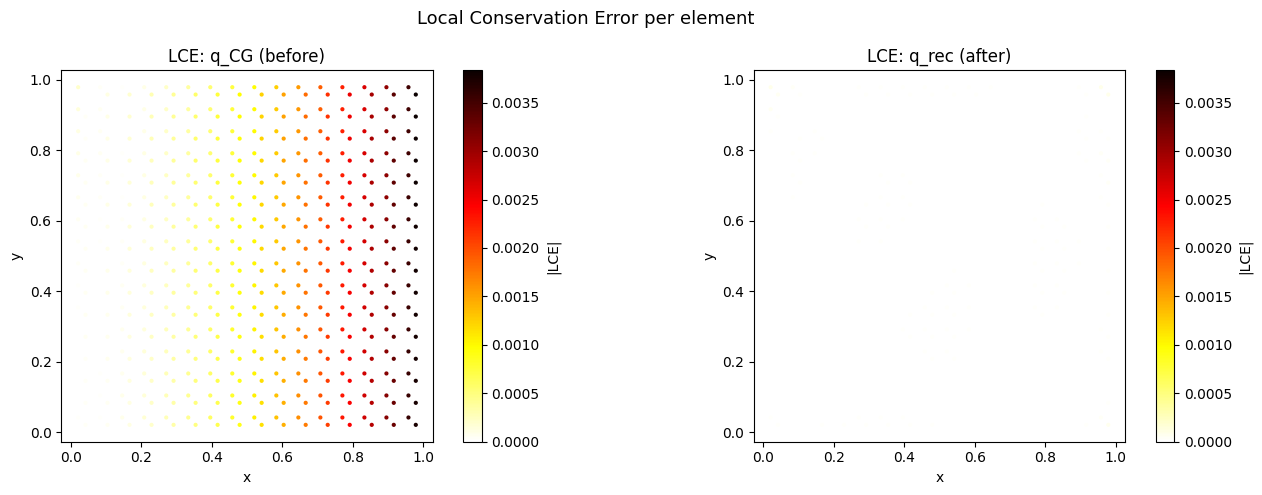

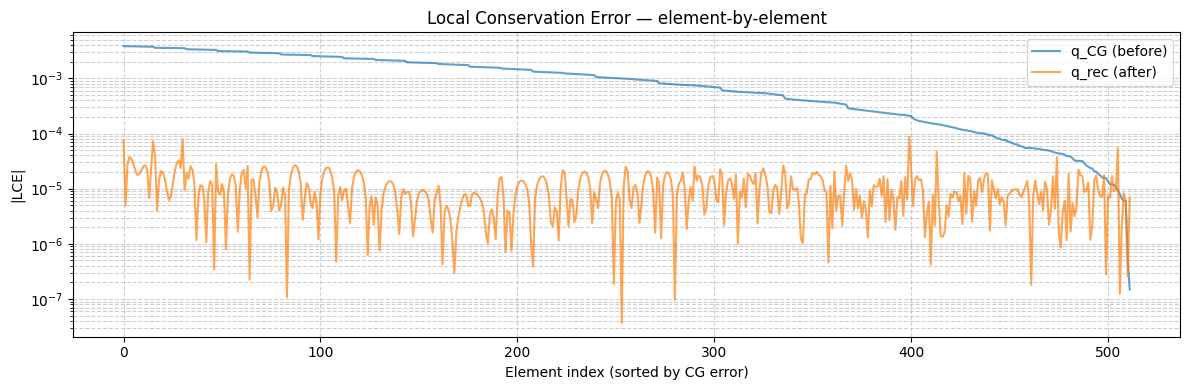

In [10]:
# ============================================================
# Cell 10: LCE plots — before and after reconstruction
# ============================================================

centroids_np = np.array([
    omega_geometry[local_cell_vertices[c]].mean(axis=0)
    for c in range(num_cells)
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lce, title in zip(
    axes,
    [lce_cg, lce_rec],
    ["LCE: q_CG (before)", "LCE: q_rec (after)"]
):
    sc = ax.scatter(
        centroids_np[:, 0], centroids_np[:, 1],
        c=np.abs(lce), cmap="hot_r",
        s=4, vmin=0, vmax=np.max(np.abs(lce_cg))
    )
    plt.colorbar(sc, ax=ax, label="|LCE|")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")

plt.suptitle("Local Conservation Error per element", fontsize=13)
plt.tight_layout()
plt.show()


# ---- Per-element bar comparison (sorted) ----
fig, ax = plt.subplots(figsize=(12, 4))
order_idx = np.argsort(np.abs(lce_cg))[::-1]
x_idx = np.arange(num_cells)

ax.semilogy(x_idx, np.abs(lce_cg[order_idx]),  label="q_CG (before)", alpha=0.7)
ax.semilogy(x_idx, np.abs(lce_rec[order_idx]), label="q_rec (after)",  alpha=0.7)
ax.set_xlabel("Element index (sorted by CG error)")
ax.set_ylabel("|LCE|")
ax.set_title("Local Conservation Error — element-by-element")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


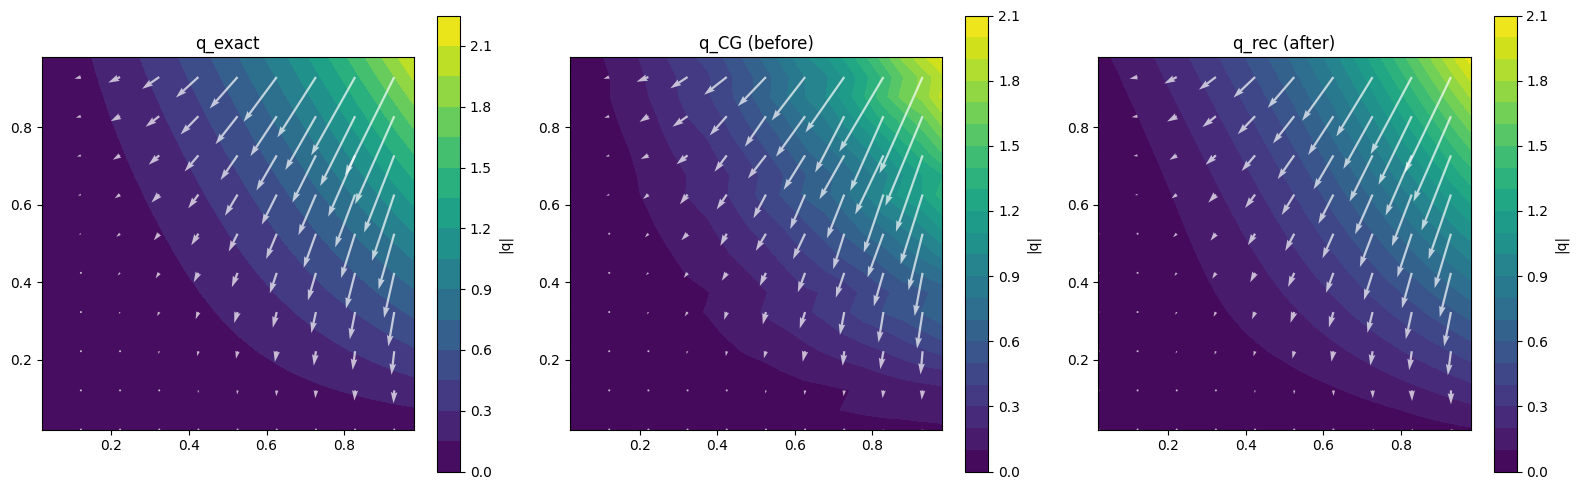

In [11]:
# ============================================================
# Cell 11: Flux vector field comparison plots
# ============================================================

n_plot = 20
xv = np.linspace(0.02, 0.98, n_plot)
yv = np.linspace(0.02, 0.98, n_plot)
Xp, Yp = np.meshgrid(xv, yv)
XY = np.column_stack([Xp.ravel(), Yp.ravel()])   # (N, 2)

# q_exact
Q_ex  = q_exact_np(XY)

# q_CG: locate one cell per query point
from dolfinx import geometry as dgeom
bb = dgeom.bb_tree(omega, omega.topology.dim)
XY_3d = np.column_stack([XY, np.zeros(len(XY))])
cell_candidates = dgeom.compute_collisions_points(bb, XY_3d)
colliding = dgeom.compute_colliding_cells(omega, cell_candidates, XY_3d)
# AdjacencyList: take first hit per point
cells_for_plot = np.array([colliding.links(i)[0] for i in range(len(XY))], dtype=np.int32)
Q_cg = q_cg_fun.eval(XY_3d, cells_for_plot)   # (N, 2)

# q_rec
with torch.no_grad():
    Q_rec = net(torch.tensor(XY, dtype=torch.float32, device=device)).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles   = ["q_exact", "q_CG (before)", "q_rec (after)"]
q_fields = [Q_ex, Q_cg, Q_rec]

for ax, Q, title in zip(axes, q_fields, titles):
    mag = np.linalg.norm(Q, axis=1).reshape(n_plot, n_plot)
    im  = ax.contourf(Xp, Yp, mag, levels=20, cmap="viridis")
    ax.quiver(Xp[::2, ::2], Yp[::2, ::2],
              Q[:, 0].reshape(n_plot, n_plot)[::2, ::2],
              Q[:, 1].reshape(n_plot, n_plot)[::2, ::2],
              scale=None, color="white", alpha=0.7)
    plt.colorbar(im, ax=ax, label="|q|")
    ax.set_title(title)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()


In [12]:
# ============================================================
# Cell 12: Summary table
# ============================================================

print("="*55)
print(f"{'Metric':<30} {'q_CG':>10} {'q_rec':>10}")
print("-"*55)
print(f"{'L2 flux error (abs)':<30} {L2_cg:>10.4e} {L2_rec:>10.4e}")
print(f"{'L2 flux error (rel)':<30} {rel_cg:>10.4e} {rel_rec:>10.4e}")
print(f"{'LCE L∞':<30} {np.max(np.abs(lce_cg)):>10.4e} {np.max(np.abs(lce_rec)):>10.4e}")
print(f"{'LCE RMS':<30} {np.sqrt(np.mean(lce_cg**2)):>10.4e} {np.sqrt(np.mean(lce_rec**2)):>10.4e}")
print(f"{'LCE mean|·|':<30} {np.mean(np.abs(lce_cg)):>10.4e} {np.mean(np.abs(lce_rec)):>10.4e}")
print("="*55)
print(f"L2 improvement: {L2_cg/L2_rec:.2f}x,  LCE RMS improvement: "
      f"{np.sqrt(np.mean(lce_cg**2))/np.sqrt(np.mean(lce_rec**2)):.2f}x")


Metric                               q_CG      q_rec
-------------------------------------------------------
L2 flux error (abs)            3.4050e-02 1.9048e-02
L2 flux error (rel)            5.8841e-02 3.2916e-02
LCE L∞                         3.8335e-03 8.7472e-05
LCE RMS                        1.7470e-03 1.4630e-05
LCE mean|·|                    1.3056e-03 1.0974e-05
L2 improvement: 1.79x,  LCE RMS improvement: 119.41x
